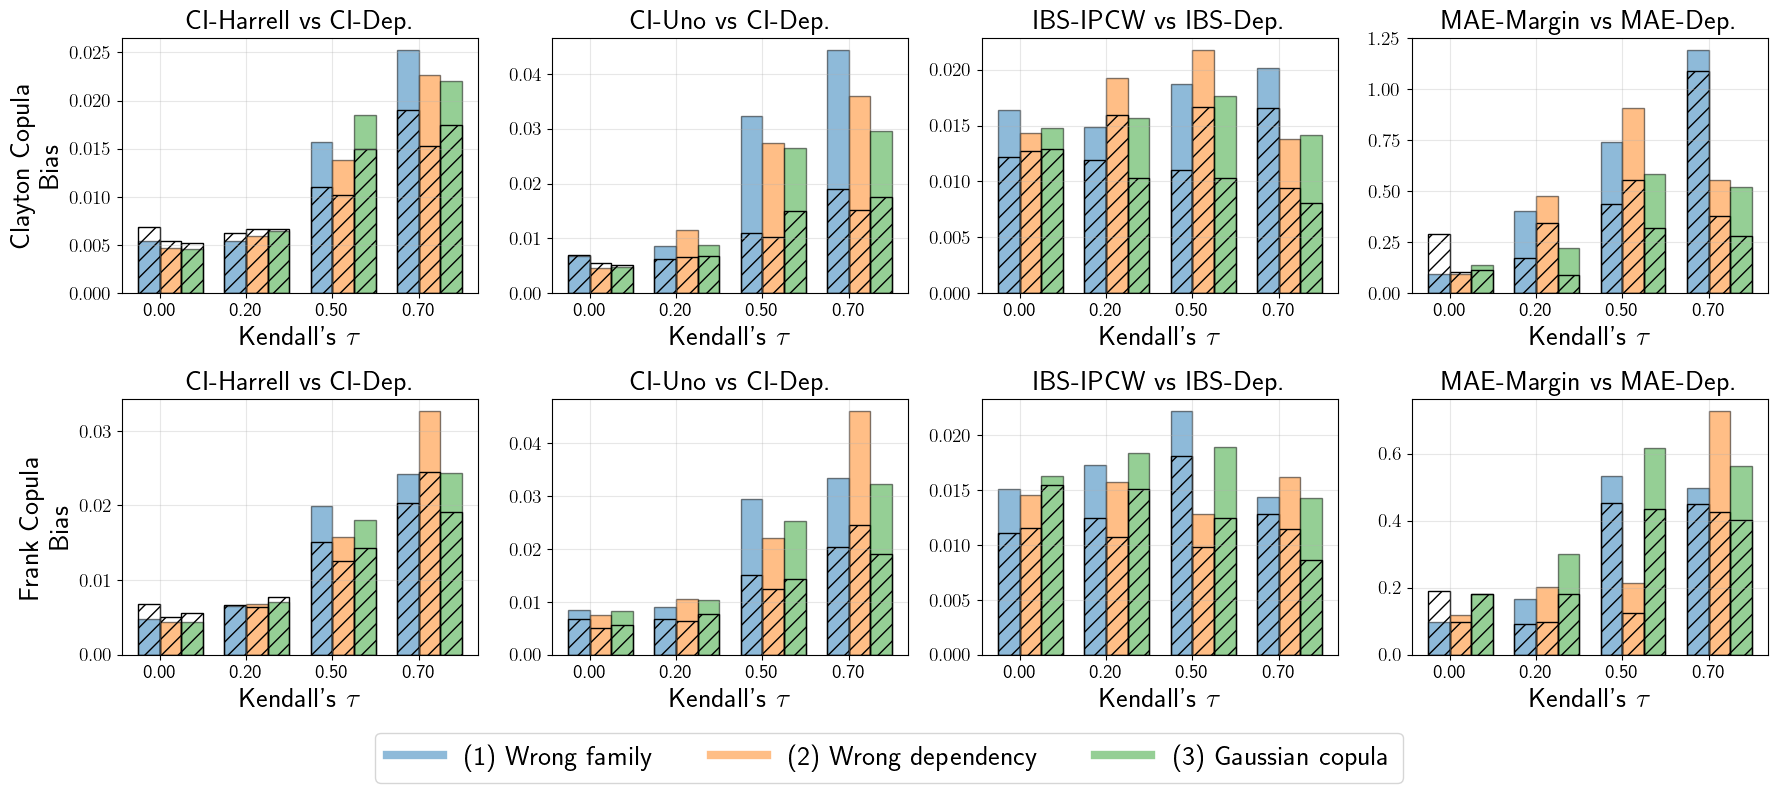

In [7]:
import numpy as np
import pandas as pd
import config as cfg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "font.size": 14.0,
    "legend.fontsize": "x-large",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

sigma_level = 1
z_threshold = 3

# Filter outliers
columns = [
    "ci_harrell_error", "ci_uno_error", "ci_dep_ipcw_error",
    "ibs_ipcw_error", "ibs_dep_bg_error",
    "mae_margin_error", "mae_dep_bg_error"
]
df = df[(np.abs((df[columns] - df[columns].mean()) / df[columns].std())
         < z_threshold).all(axis=1)]

# Keep only selected experiments
keep_exps = ["family", "dep", "gaussian"]
df = df[df["experiment"].isin(keep_exps)]
experiments = sorted(df["experiment"].unique())  # 3 experiments

# Group
grouped = df.groupby(["experiment", "copula_name", "k_tau", "n_samples"])
mean_errors = grouped.mean().reset_index()
std_errors = grouped.std().reset_index()

# Metrics to plot
error_columns = [
    ("ci_harrell_error", "ci_dep_ipcw_error", "CI-Harrell", "CI-Dep."),
    ("ci_uno_error", "ci_dep_ipcw_error", "CI-Uno", "CI-Dep."),
    ("ibs_ipcw_error", "ibs_dep_bg_error", "IBS-IPCW", "IBS-Dep."),
    ("mae_margin_error", "mae_dep_bg_error", "MAE-Margin", "MAE-Dep.")
]

copula_rows = {"clayton": 0, "frank": 1}
tau_keep = [0.0, 0.2, 0.5, 0.7]

# --- Plot ---
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

for col_idx, (indep_metric, dep_metric, indep_name, dep_name) in enumerate(error_columns):
    for copula_name, row_idx in copula_rows.items():
        ax = axs[row_idx, col_idx]

        tau_present = (mean_errors["copula_name"] == copula_name) & \
                      (mean_errors["n_samples"] == 10000)
        tau_vals_panel = (mean_errors.loc[tau_present, "k_tau"]
                          .drop_duplicates()
                          .sort_values())
        tau_vals_panel = [t for t in tau_keep if t in set(tau_vals_panel)]

        x = np.arange(len(tau_vals_panel))  # positions for τ groups
        width = 0.25  # bar width

        for i, exp in enumerate(experiments):
            mask = (
                (mean_errors["copula_name"] == copula_name) &
                (mean_errors["experiment"] == exp) &
                (mean_errors["n_samples"] == 10000) &
                (mean_errors["k_tau"].isin(tau_vals_panel))
            )
            copula_data = mean_errors[mask].sort_values("k_tau")

            indep_vals = copula_data[indep_metric].values
            dep_vals = copula_data[dep_metric].values

            ax.bar(x + i*width - width/2, indep_vals,
                width=width, color=f"C{i}", edgecolor="k",
                linewidth=1, alpha=0.5, label=indep_name)

            ax.bar(x + i*width - width/2, dep_vals,
                width=width, color=f"C{i}", edgecolor="k",
                linewidth=1, fill=False, hatch="//", label=dep_name)

        ax.set_xticks(x)
        ax.set_xticklabels([f"{t:.2f}" for t in tau_vals_panel])
        ax.set_xlabel("Kendall's $\\tau$")
        if col_idx == 0:
            ax.set_ylabel(f"{copula_name.capitalize()} Copula\nBias")
        ax.set_title(f"{indep_name} vs {dep_name}")
        ax.grid(True, alpha=0.3)

# --- Custom legend handles ---
handles = [
    Line2D([0], [0], color="C0", lw=6, label="(1) Wrong family", alpha=0.5),
    Line2D([0], [0], color="C1", lw=6, label="(2) Wrong dependency", alpha=0.5),
    Line2D([0], [0], color="C2", lw=6, label="(3) Gaussian copula", alpha=0.5),
]

fig.legend(handles=handles,
           loc="lower center",
           ncol=3,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
            format="pdf", bbox_inches="tight")
plt.show()